### We are trying to classify a dataset of 400 images, each containing 4096 pixels, i.e dimensions. We'll use various dimensionality reduction techniques as well as clustering methods. This is an unsupervised clustering problem. Moreover, we add 

* a few metrics (both internal and external) to see how the code performs 
* see how it performs for a bigger data set. 

### Also we made slight modifications to the code:

* In DBSCAN, we needed some small parameter for eps around 5-10, motivated by the sne results. These show that the intra-cluster distance is around 10 or so and we choose 10. 
* In PCA, we converted feature names to strings.


In [2]:
import matplotlib.pyplot as plt
import random

import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, MDS, LocallyLinearEmbedding, TSNE # There are more. Check them out

from sklearn.datasets import fetch_olivetti_faces



In [3]:
# Faces is a dictionary that contains the actual images, the data, the target (i.e the true labels) and a description of the dataset

faces = fetch_olivetti_faces()



`faces` is a dictionary with 4 keys:
* images: The actual 400 black and white images of 64x64 pixels of people.
* data: Same data as images, but 400 samples of 4096 columns (the pixels converted to input features)
* target: An array of 400 integers, representing the class (each class represents a different person)
* description: A description of the dataset. Shown below.

In [4]:
# Description of the dataset
print(faces.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and 
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position 
    (with tolerance for some side movement).

**Data Set Characteristics:**

    =================   =====================
    Classes    

In [5]:
# 400 images, 64 by 64 pixels.
faces['images'].shape

(400, 64, 64)

<Figure size 640x480 with 0 Axes>

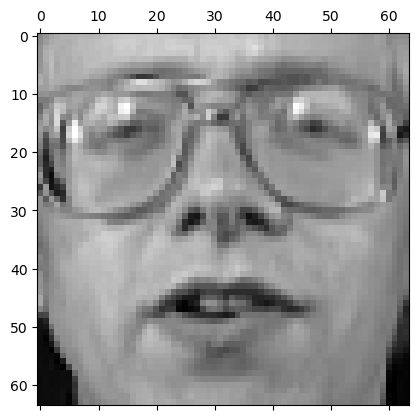

In [6]:
# We visualize here the 10th training data record

SAMPLE_RECORD_NUMBER = 10 

plt.gray() 
plt.matshow(faces.images[SAMPLE_RECORD_NUMBER]) 
plt.show() 

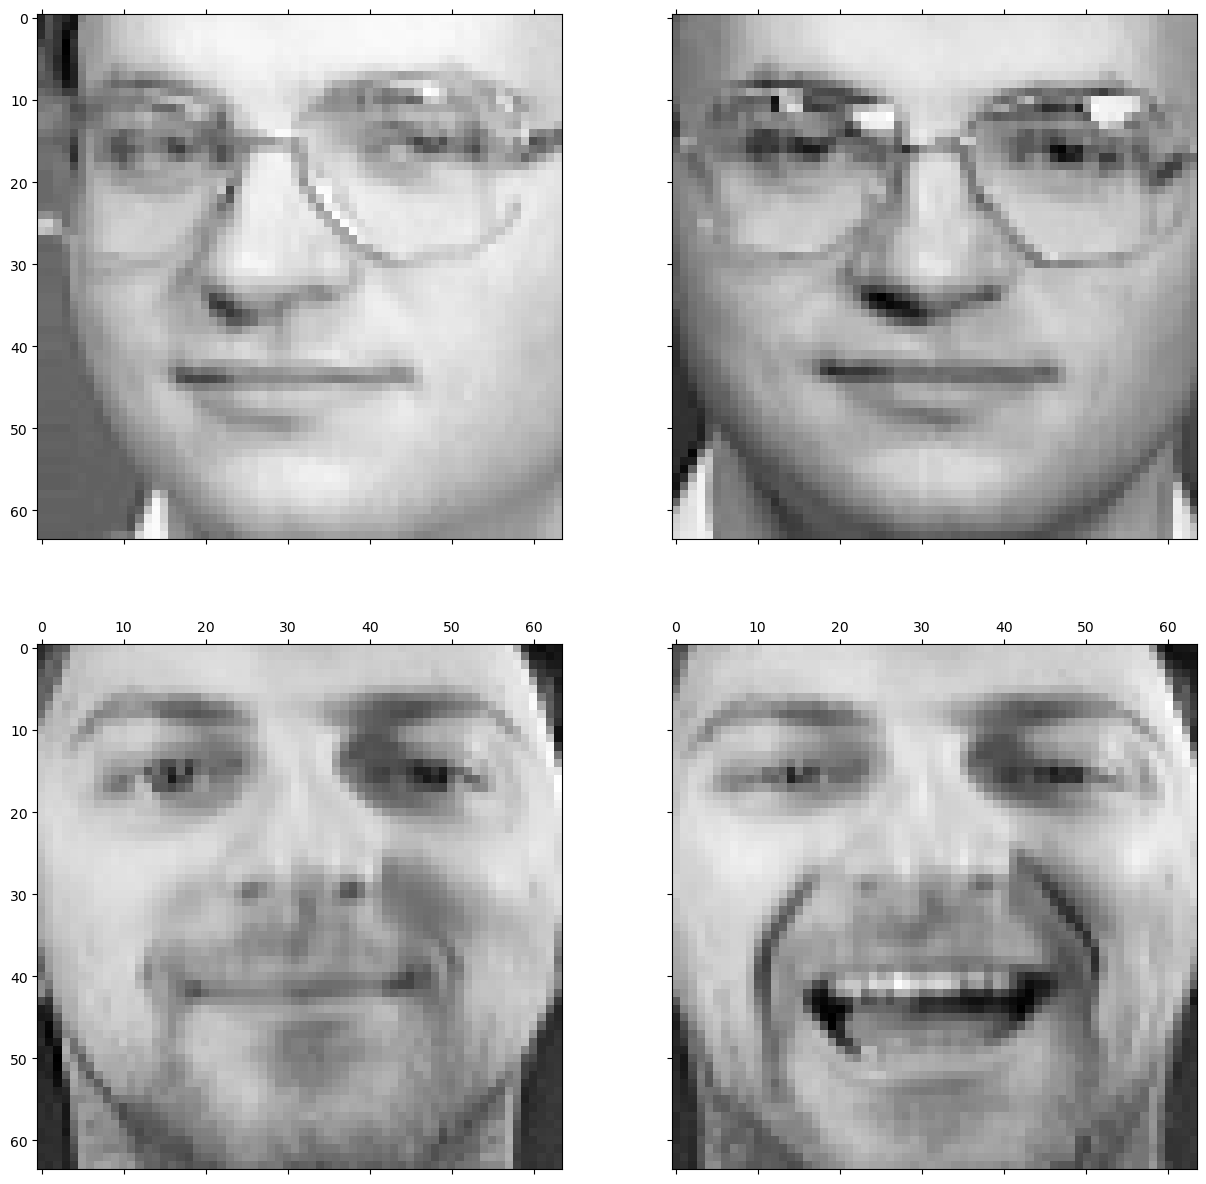

In [7]:
grid_size = 2 # grid_size is the # of clusters

fig, axes = plt.subplots(grid_size, grid_size, sharex=True, sharey=True,figsize=(15, 15))
j=58 # j runs over the different 

for row in axes:
    for i in range(grid_size):
        row[i].matshow(faces.images[j])
        j+=1

plt.show()

In [8]:
# We simplify to 70 images

In [9]:
N_IMAGES = 70

df = pd.DataFrame(faces['data'][:N_IMAGES])

In [10]:
# As we expected, 4096 input features...
df.shape

(70, 4096)

# Manifold Plots

Let's use Manifold Learning to plot the images...

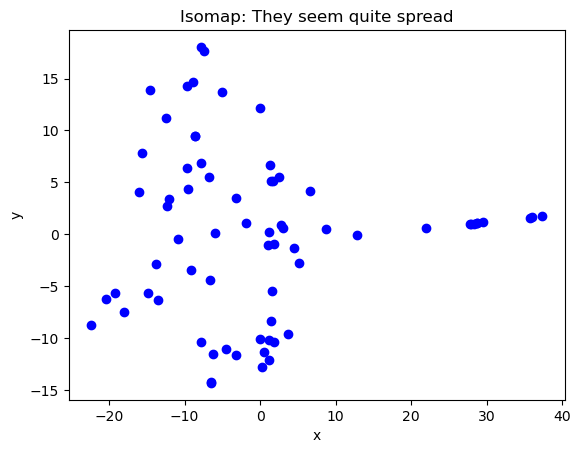

In [11]:
cols = ['x', 'y']

# First we use isomap: nonlinear dimensionality reduction technique by preserving geodesic distances
isomap = Isomap(
    n_neighbors=5, #num of neighbors for KNN 
    n_components=2, # 2D data as a result
    n_jobs=-1 # The number of parallel jobs to run
)
isomap_result = isomap.fit_transform(df)
isomap_result = pd.DataFrame(isomap_result)
isomap_result.columns = cols

plt.scatter(isomap_result['x'], isomap_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Isomap: They seem quite spread')
plt.show()

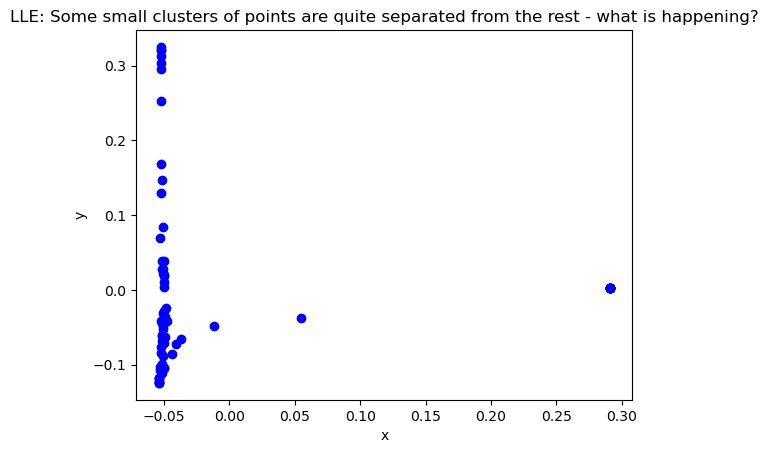

In [12]:
# Then we use LLE: Nonlinear dimensionality reduction that preserves local neighborhood geometry

lle = LocallyLinearEmbedding(
    n_neighbors=5, # Number of neighbors to consider for each point
    n_components=2, # Number of coordinates for the manifold
    reg=0.001, # Regularization constant,
    method='standard', # Could be {‘standard’, ‘hessian’, ‘modified’, ‘ltsa’} for all of the versions of LLE we saw
    random_state=0,  # Determines the random number generator
    n_jobs=-1 # The number of parallel jobs to run
)
lle_result = lle.fit_transform(df)
lle_result = pd.DataFrame(lle_result)
lle_result.columns = cols
plt.scatter(lle_result['x'], lle_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('LLE: Some small clusters of points are quite separated from the rest - what is happening?')
plt.show()

/Users/nikos/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


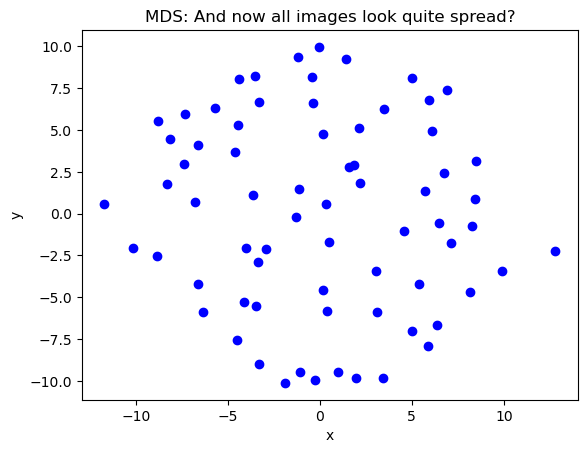

In [13]:
# Multi-dimensional scaling algorithms: preserving pairwise distances
mds = MDS(
    n_components=2, # Number of dimensions in which to immerse the dissimilarities.
    metric=True, # To select metric or non-metric MDS
    n_init=4, #Maximum number of iterations for the optimization
    max_iter=300, # Maximum number of iterations of the SMACOF algorithm for a single run
    verbose=0, # Level of verbosity.
    eps=0.001, 
    n_jobs=-1, 
    random_state=0, 
    dissimilarity='euclidean'
)
mds_result = mds.fit_transform(df)
mds_result = pd.DataFrame(mds_result)
mds_result.columns = cols
plt.scatter(mds_result['x'], mds_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MDS: And now all images look quite spread?')
plt.show()

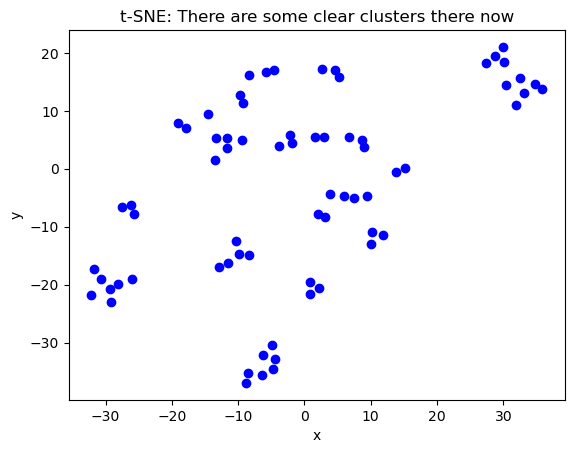

Are there around 7-10 clusters there or it is my imagination just?


In [14]:
# Now we use SNE: preserves local structure
t_sne = TSNE(
    n_components=2,
    # I had to play with perplexity quite a bit: WHAT HAPPENS IF YOU INCREASE/DECREASE IT?
    perplexity=5.6, 
    metric='euclidean', 
    # Can be random or pca. Try both!
    init='pca', 
    verbose=0, 
    random_state=0, 
    # You can also put below 'exact', but you will have to approx double the perplexity factor
    method='barnes_hut',
    n_jobs=-1
)
t_sne_result = t_sne.fit_transform(df)
t_sne_result = pd.DataFrame(t_sne_result)
t_sne_result.columns = cols
plt.scatter(t_sne_result['x'], t_sne_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('t-SNE: There are some clear clusters there now')
plt.show()
print('Are there around 7-10 clusters there or it is my imagination just?')

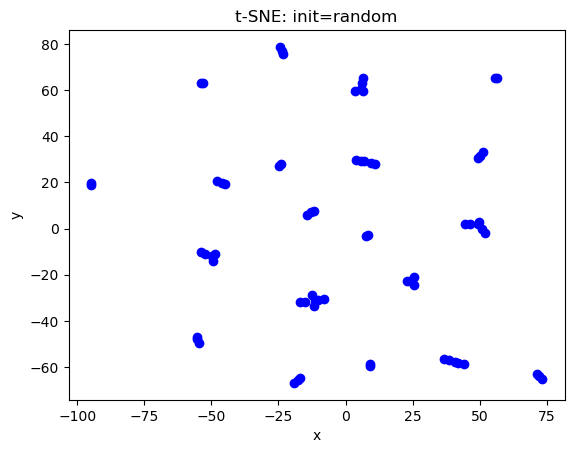

In [28]:
# Now we use SNE: preserves local structure
t_sne = TSNE(
    n_components=2, #Dimension of the embedded space
    # I had to play with perplexity quite a bit: WHAT HAPPENS IF YOU INCREASE/DECREASE IT? 
    #Perplexity is the number of nearset neighbours that is used, so high perplexity-> big clusters, low ->small ones
    perplexity= 5.6, 
    metric='euclidean', 
    # Can be random or pca. Try both!
    init='random', 
    verbose=0, 
    random_state=0, 
    # You can also put below 'exact', but you will have to approx double the perplexity factor
    method='barnes_hut',
    n_jobs=-1
)
t_sne_result = t_sne.fit_transform(df)
t_sne_result = pd.DataFrame(t_sne_result)
t_sne_result.columns = cols
plt.scatter(t_sne_result['x'], t_sne_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('t-SNE: init=random')
plt.show()
print('')

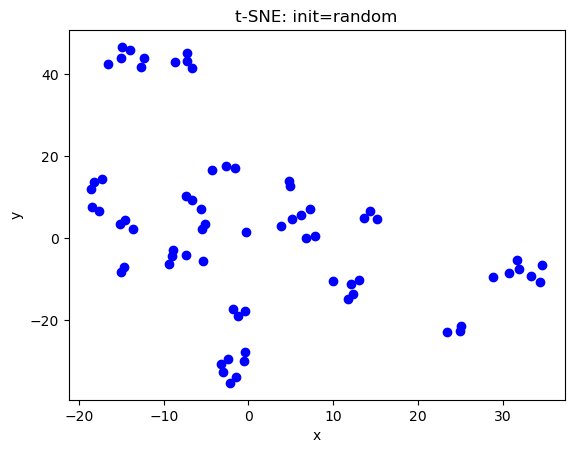

In [22]:
# Now we use SNE: preserves local structure
t_sne = TSNE(
    n_components=2, #Dimension of the embedded space
    # I had to play with perplexity quite a bit: WHAT HAPPENS IF YOU INCREASE/DECREASE IT?
    perplexity=5, # Related to the relationships of the number of nearest neighbors
    metric='euclidean', 
    # Can be random or pca. Try both!
    init='random', 
    verbose=0, 
    random_state=0, 
    # You can also put below 'exact', but you will have to approx double the perplexity factor
    method='barnes_hut',
    n_jobs=-1
)
t_sne_result = t_sne.fit_transform(df)
t_sne_result = pd.DataFrame(t_sne_result)
t_sne_result.columns = cols
plt.scatter(t_sne_result['x'], t_sne_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('t-SNE: init=random')
plt.show()
print('')

# Clustering

Let's cluster that data that came out of t-SNE and see if we can more or less guess the number of groups/clusters (classes, **different people**) we have in there...

In [13]:
# For clustering first we use DBSCAN: identifies clusters of arbitrary shape based on density of data points. We note that we need some small parameter for eps of the order of 1,
# motivated by the sne results. These show that the intra-cluster distance is around 10 or so and we choose 10.  
dbscan = DBSCAN(
    eps=10, # Maximum distance between two samples for one to be considered as in the neighborhood of the other.
    min_samples=5, # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    
)
dbscan_clusters = dbscan.fit_predict(t_sne_result)


In [14]:
print(dbscan_clusters)

[ 0  1  0  1  1  1  0  0  0  1  2  2  2  2  2  2  2  2  2  2  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1  3  3  3  3  3  3  3  4  4 -1  4  4 -1  4  4 -1  4]


In [15]:
print(t_sne_result)

            x          y
0   -9.894332 -14.726674
1   11.780926 -11.459215
2   -8.308903 -14.843344
3  -17.806120   7.095377
4   10.168070 -10.993045
..        ...        ...
65 -27.566973  -6.561839
66 -25.967487 -18.968187
67 -28.091631 -19.849602
68 -25.689316  -7.859347
69 -32.172371 -21.783649

[70 rows x 2 columns]


In [16]:
print('Num. samples without cluster:', (dbscan_clusters == -1).sum())
# DBSCAN thinks there are 4 different people:
print('Clusters: ', set(dbscan_clusters))

# The -1 cluster are those samples that are considered noise (don't belong to any cluster)
# Now we will add these clusters to the different Manifold Learning results, and plot them:

Num. samples without cluster: 6
Clusters:  {0, 1, 2, 3, 4, -1}


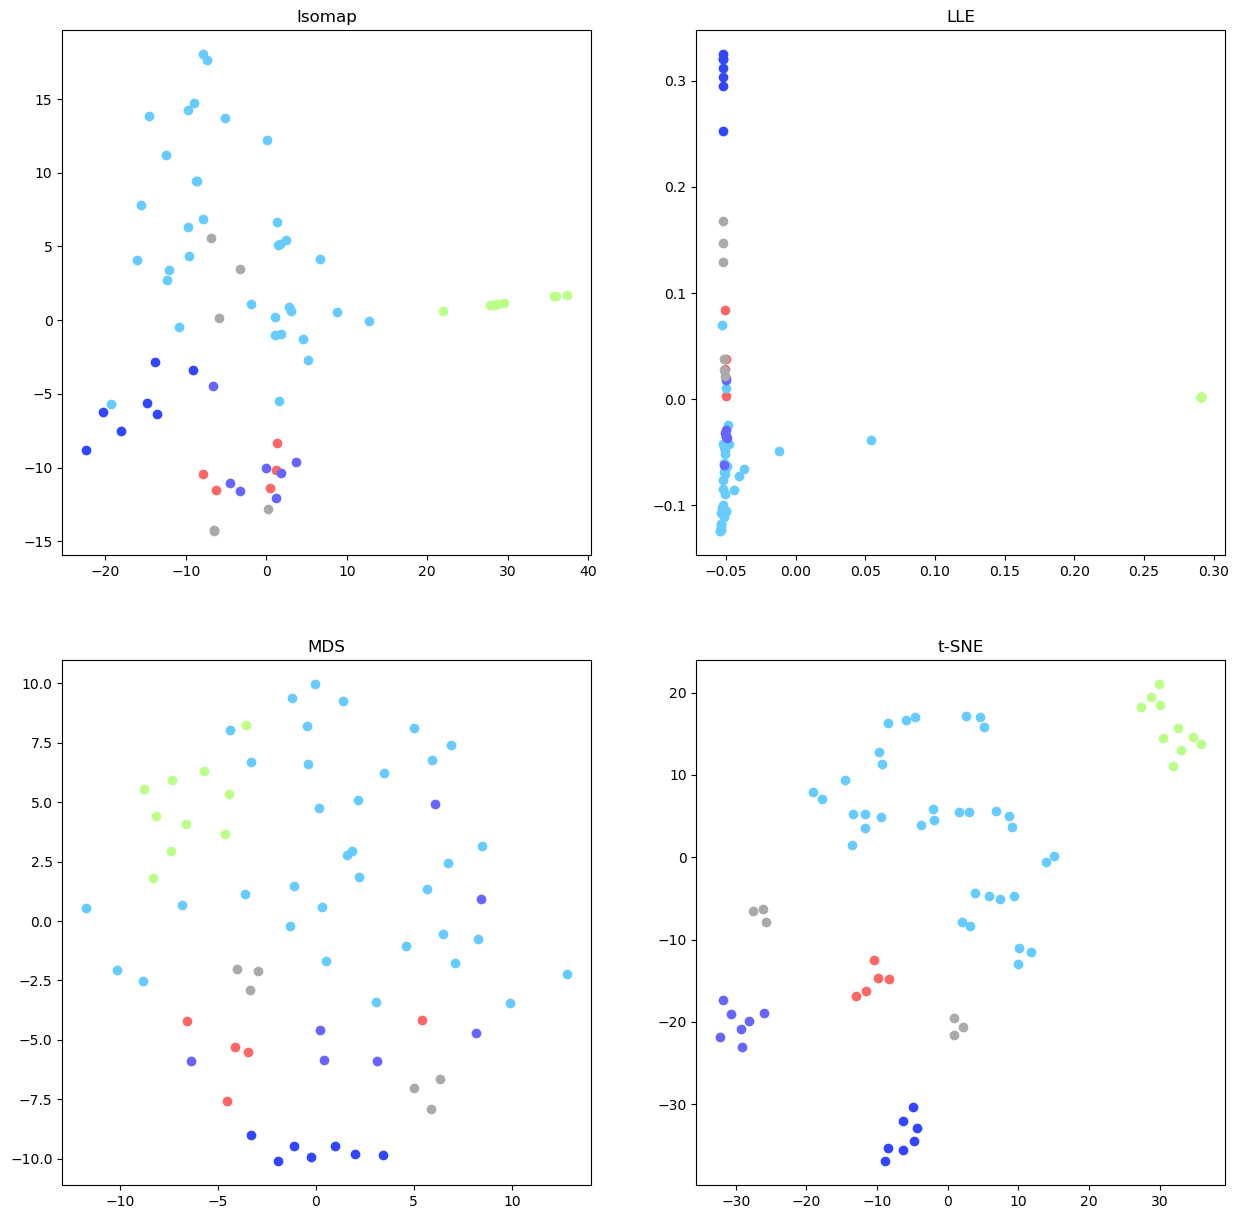

In [17]:
# We plot the results of the different manifold learning techniques with DBSCAN
results = [isomap_result, lle_result, mds_result, t_sne_result]
algos = ['Isomap', 'LLE', 'MDS', 't-SNE']

palette = [
        '#aaaaaa', '#ff6666', '#66ccff', '#bbff88', '#3346ff', '#6666ff', '#e566ff', '#66ff99', 
        '#7cb9e8', '#b0bf1a', '#5d8aa8', '#efdecd', '#3b7a57', '#967117', '#cce6ff',
        '#4da6ff', '#e60073', '#2200cc', '#0088cc', '#19ffff', '#1eb300', '#805500',
]

clusters = set(dbscan_clusters)

for r in results:
    r['dbscan'] = dbscan_clusters


fig, axes = plt.subplots(2, 2, figsize=(15, 15))
res_index = 0

for row in axes:
    for i in range(2):
        res = results[res_index]
        for c in clusters:
            cluster_data = res[res['dbscan']==c]
            row[i].scatter(cluster_data['x'],cluster_data['y'], color=palette[c+1])
        row[i].title.set_text(algos[res_index])
        res_index+=1

plt.show()

In [ ]:
# Clearly t-SNE performs a lot better. 

In [18]:
df['clusters'] = dbscan_clusters
print(df['clusters'])

0     0
1     1
2     0
3     1
4     1
     ..
65   -1
66    4
67    4
68   -1
69    4
Name: clusters, Length: 70, dtype: int64


In [19]:
print("Available clusters:", set(df['clusters']))

Available clusters: {0, 1, 2, 3, 4, -1}


This cluster has 35 photos


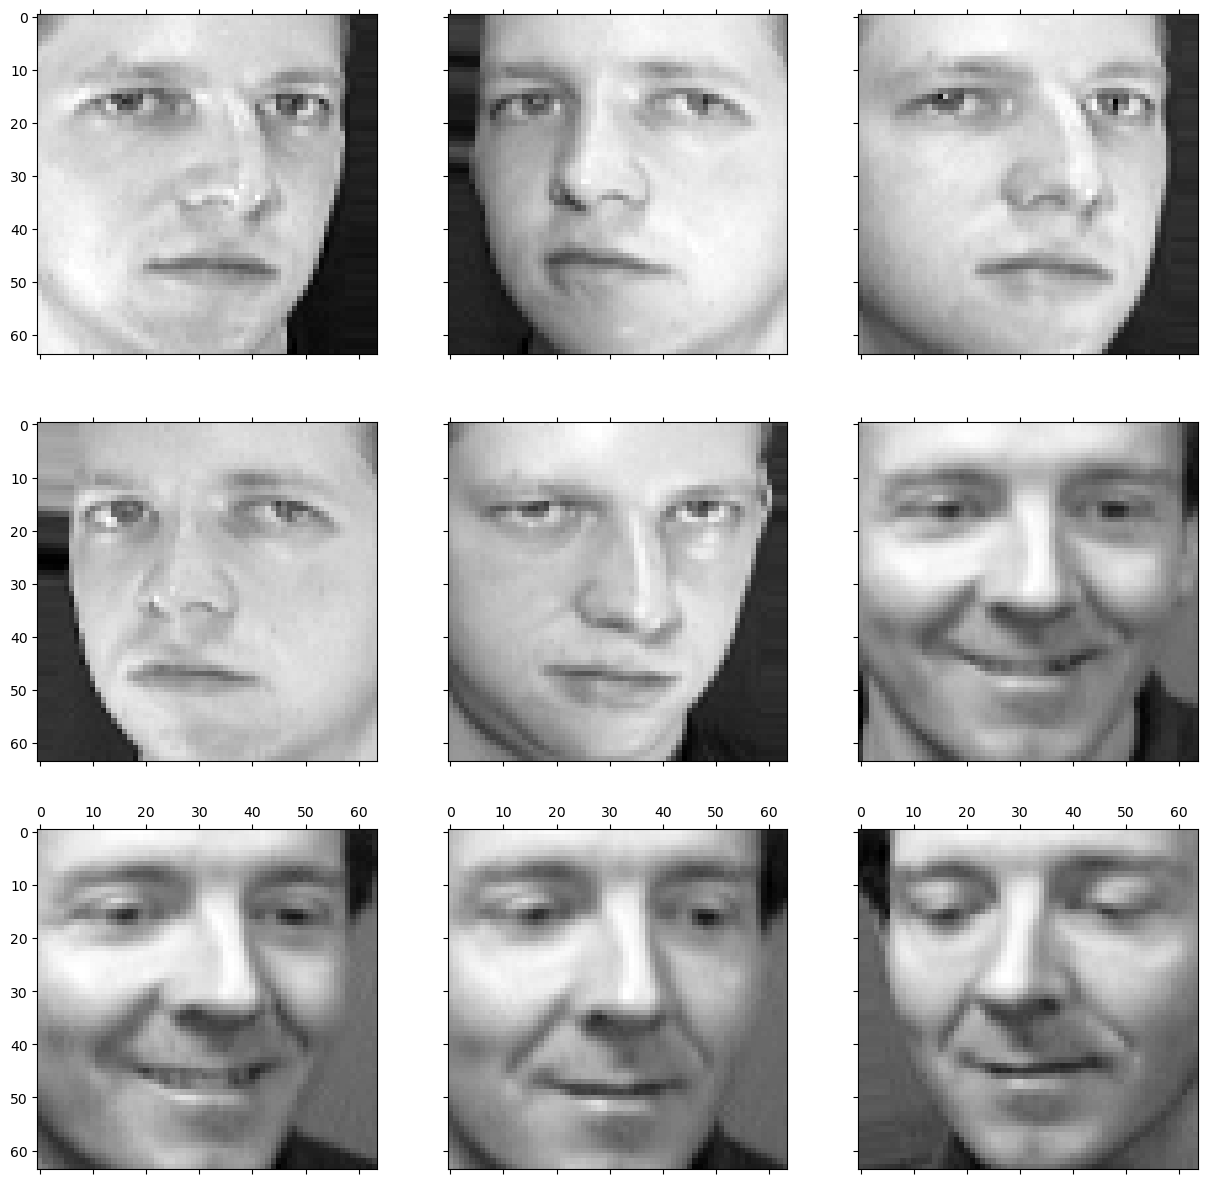

In [20]:
# Choose between -1 and len(set(dbscan_clusters))
CLUSTER_TO_DISPLAY = 1

cluster_images = df[df['clusters'] == CLUSTER_TO_DISPLAY]

print('This cluster has',len(cluster_images), 'photos')

# IF THE CLUSTER HAS LESS THAN 9 IMAGES, THEY WILL BE REPEATED BELOW:
grid_size = 3
fig, axes = plt.subplots(grid_size, grid_size, sharex=True, sharey=True,figsize=(15, 15))

img_count=0

for row in axes:
    for i in range(grid_size):
        row[i].matshow(np.array(cluster_images.iloc[img_count % len(cluster_images)][:4096]).reshape(64, 64))
        img_count+=1

plt.show()

## Kind of works...

The best clusters for me where the young man of the very first picture we showed above in this notebook, and all of the gentlemen with glasses. 

t-SNE's low-dimensional visualisation kind of gave us the impression that there were between 5 and 10 clusters of data - which allowed us to tune DBSCAN to achieve an OK result to group the 70 pictures.



In [21]:
# Now we use PCA 
vanilla_pca = PCA(n_components=2, svd_solver='auto')
# Converting feature names to str
df.columns = df.columns.astype(str)
v_pca = vanilla_pca.fit_transform(df)
print('Shape of the PCA-transformed data: ',v_pca.shape)
print('Those are', v_pca.shape[1], 'components')
print('Variance explained: ', round(100*sum(vanilla_pca.explained_variance_ratio_), 2), '% of the total')

Shape of the PCA-transformed data:  (70, 2)
Those are 2 components
Variance explained:  38.51 % of the total


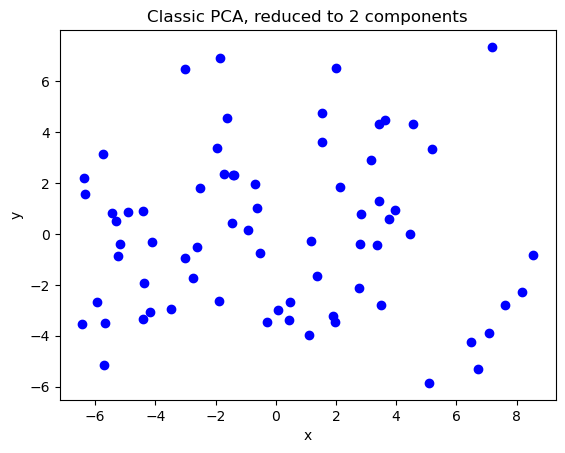

In [22]:
v_pca_result = pd.DataFrame(v_pca)
v_pca_result.columns = cols
plt.scatter(v_pca_result['x'], v_pca_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Classic PCA, reduced to 2 components')
plt.show()

It seems to happen the same as with MDS... the data is spread everywhere.

##### Let's plot our OK-ish t-SNE-based clusters in that PCA 2D plot:

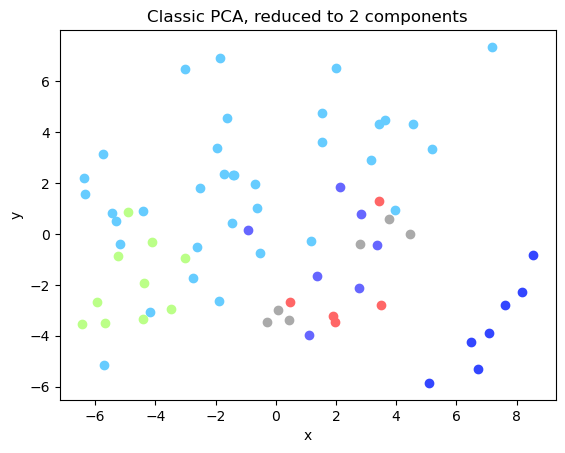

In [23]:
v_pca_result['dbscan'] = dbscan_clusters

for c in clusters:
    cluster_data = v_pca_result[v_pca_result['dbscan'] == c]
    plt.scatter(cluster_data['x'], cluster_data['y'], color=palette[c+1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Classic PCA, reduced to 2 components')
plt.show()

That is actually not too bad! Some of the clusters we discovered using t-SNE (non-linear Manifold Learning) are located nearby, and without overlaps, in PCA (linear Dimensionality Reduction technique).

This means that there are _some linear relationships_ in our data that can be exploited by traditional Dimensionality Reduction techniques, even though PCA's 2 components are only able to explain around 40% of the original variance.

Maybe we could have done our clustering directly on the original data? Or in a PCA (or other Dimensionality Reduction) with some higher number of components?

In [24]:
# I had to play with these two parameters a lot to obtain a result similar
# to what we had after t-SNE!! 
# Without the knowledge from t-SNE and/or the target variable provided in 
# the dataset (faces['target']), this would have been a big guess to know how many clusters is
# the correct result... or maybe not: what could we have done here?
dbscan = DBSCAN(
    eps=8.5,
    min_samples=2,
    
)
dbscan_clusters2 = dbscan.fit_predict(df)

In [25]:
print('Num. samples without cluster:', (dbscan_clusters2 == -1).sum())
print('Clusters: ', set(dbscan_clusters2))

Num. samples without cluster: 3
Clusters:  {0, 1, 2, 3, 4, 5, -1}


In [26]:
df['clusters2'] = dbscan_clusters2

Num. Images in Cluster: 10


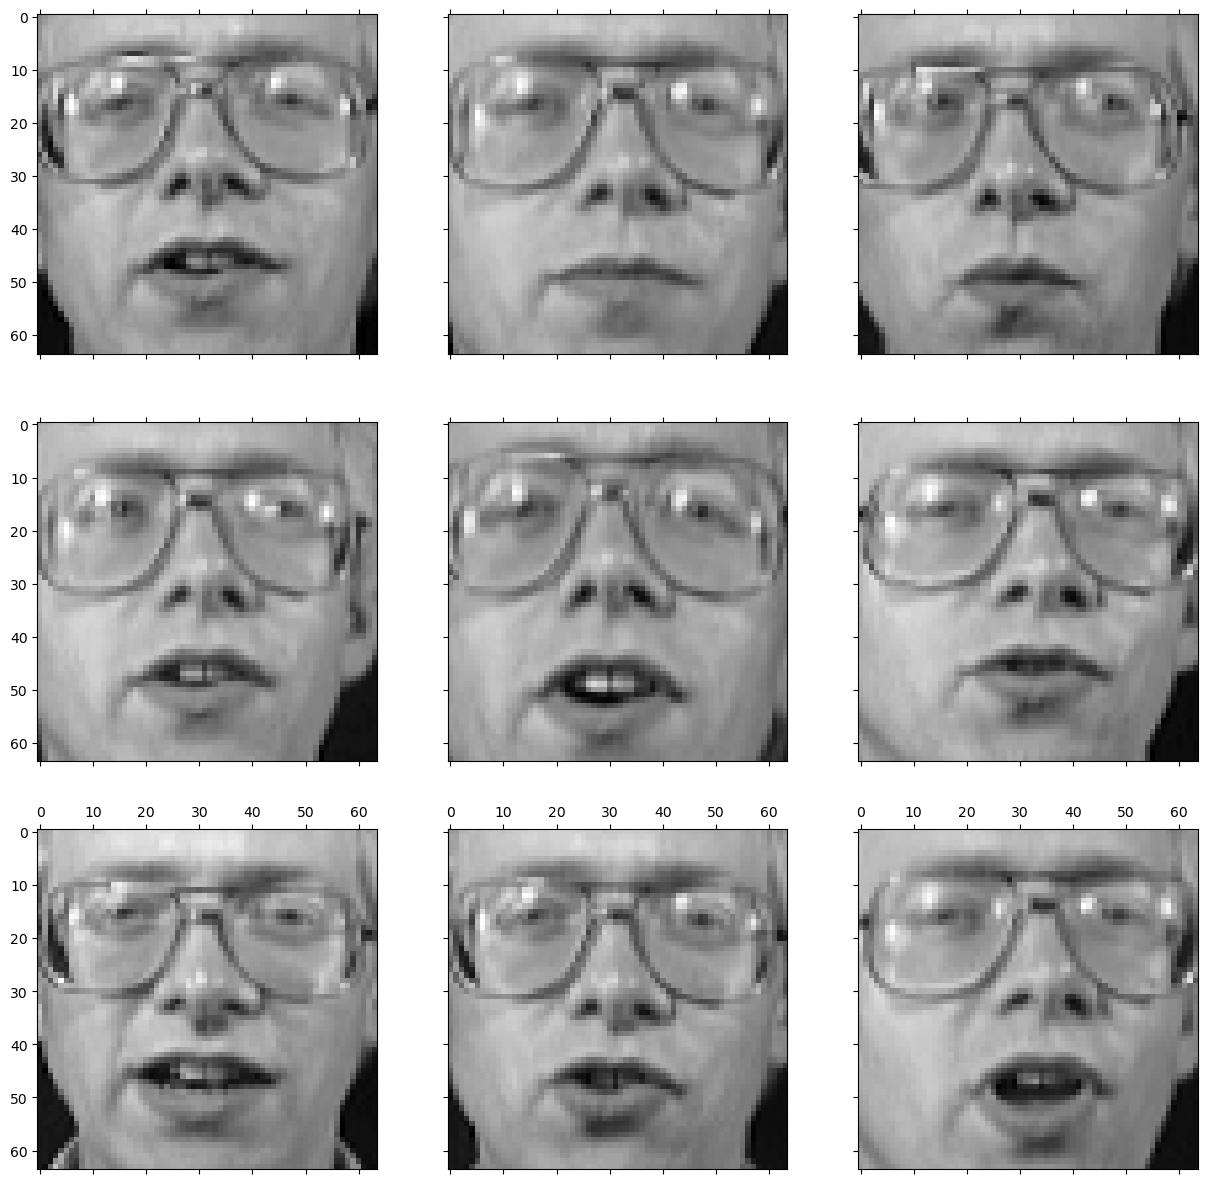

Seems like the clusters work - and contain the same person in all of them!


In [27]:
# Choose between -1 and len(dbscan_clusters2)
CLUSTER_TO_DISPLAY = 3

cluster_images = df[df['clusters2'] == CLUSTER_TO_DISPLAY]

print('Num. Images in Cluster:', len(cluster_images))

# IF THE CLUSTER HAS LESS THAN 9 IMAGES, THEY WILL BE REPEATED BELOW:
grid_size = 3
fig, axes = plt.subplots(grid_size, grid_size, sharex=True, sharey=True,figsize=(15, 15))

img_count=0

for row in axes:
    for i in range(grid_size):
        row[i].matshow(np.array(cluster_images.iloc[img_count % len(cluster_images)][:4096]).reshape(64, 64))
        img_count+=1

plt.show()
print('Seems like the clusters work - and contain the same person in all of them!')

It is possible to differentiate the 2 gentlemen using the same pair of glasses.

**Note:** The first time we clustered images, we used only 2 dimensions (those provided by t-SNE), and got fair-enough results. The second time, we used the 4096 original dimensions (all the pixels) to do the clustering!! In a very large dataset that would have taken ages!! So, while the second results are maybe slightly better for what I observed in the clusters, t-SNE helped analyse our data to seek an ok-ish number of clusters that there should be, and then quickly apply any clustering algorithm there.

In [28]:
# More than 70 images. We try t-SNE in the following lines:
N_IMAGES = 100

df = pd.DataFrame(faces['data'][:N_IMAGES])

In [29]:
# As we expected, 4096 input features...
df.shape

(100, 4096)

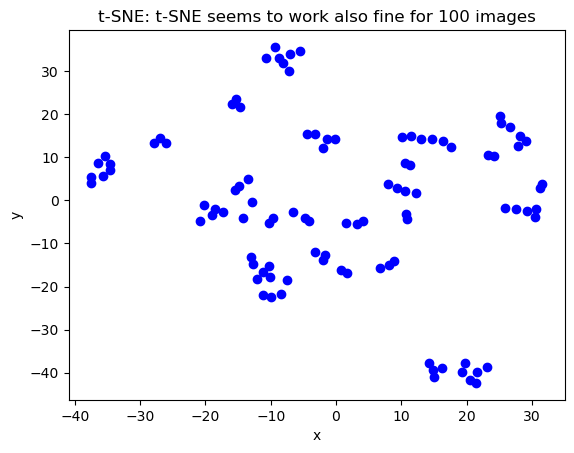

In [30]:
cols = ['x', 'y']
t_sne = TSNE(
    n_components=2,
    # I had to play with perplexity quite a bit: WHAT HAPPENS IF YOU INCREASE/DECREASE IT?
    perplexity=5.6, 
    metric='euclidean', 
    # Can be random or pca. Try both!
    init='pca', 
    verbose=0, 
    random_state=0, 
    # You can also put below 'exact', but you will have to approx double the perplexity factor
    method='barnes_hut',
    n_jobs=-1
)
t_sne_result = t_sne.fit_transform(df)
t_sne_result = pd.DataFrame(t_sne_result)
t_sne_result.columns = cols
plt.scatter(t_sne_result['x'], t_sne_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('t-SNE: t-SNE seems to work also fine for 100 images')
plt.show()

In [36]:
dbscan = DBSCAN(
    eps=10, # Maximum distance between two samples for one to be considered as in the neighborhood of the other.
    min_samples=5, # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    
)
dbscan_clusters = dbscan.fit_predict(t_sne_result)


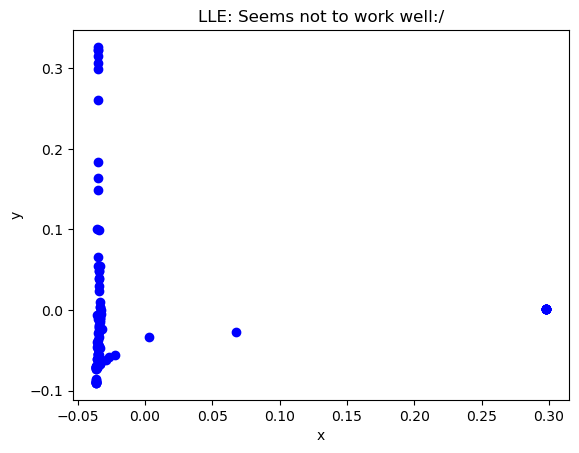

In [31]:
# LLE would be very good if there existed some linear relationships. We try it below:
lle = LocallyLinearEmbedding(
    n_neighbors=5, 
    n_components=2, 
    reg=0.001, 
    method='standard', # Could be {‘standard’, ‘hessian’, ‘modified’, ‘ltsa’} for all of the versions of LLE we saw
    random_state=0, 
    n_jobs=-1
)
lle_result = lle.fit_transform(df)
lle_result = pd.DataFrame(lle_result)
lle_result.columns = cols
plt.scatter(lle_result['x'], lle_result['y'], color='b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('LLE: Seems not to work well:/')
plt.show()

In [37]:
# Metrics 
# First we start with internal, and we use  Silhouette Coefficient

from sklearn import metrics
metrics.silhouette_score(t_sne_result, dbscan_clusters , metric='euclidean')

0.26034987

In [38]:
print("t-sne+DBSCAN: Weak structure — clusters exist but are not well separated")

t-sne+DBSCAN: Weak structure — clusters exist but are not well separated


In [44]:
#External clustering 
from sklearn.metrics import normalized_mutual_info_score
y_true = faces['target'][:N_IMAGES]

# Normalized mutual Information 

nmi = normalized_mutual_info_score(y_true, dbscan_clusters)
print(nmi)


0.603434635107004


In [45]:
print("This indicates quite a good match!")

This indicates quite a good match!
